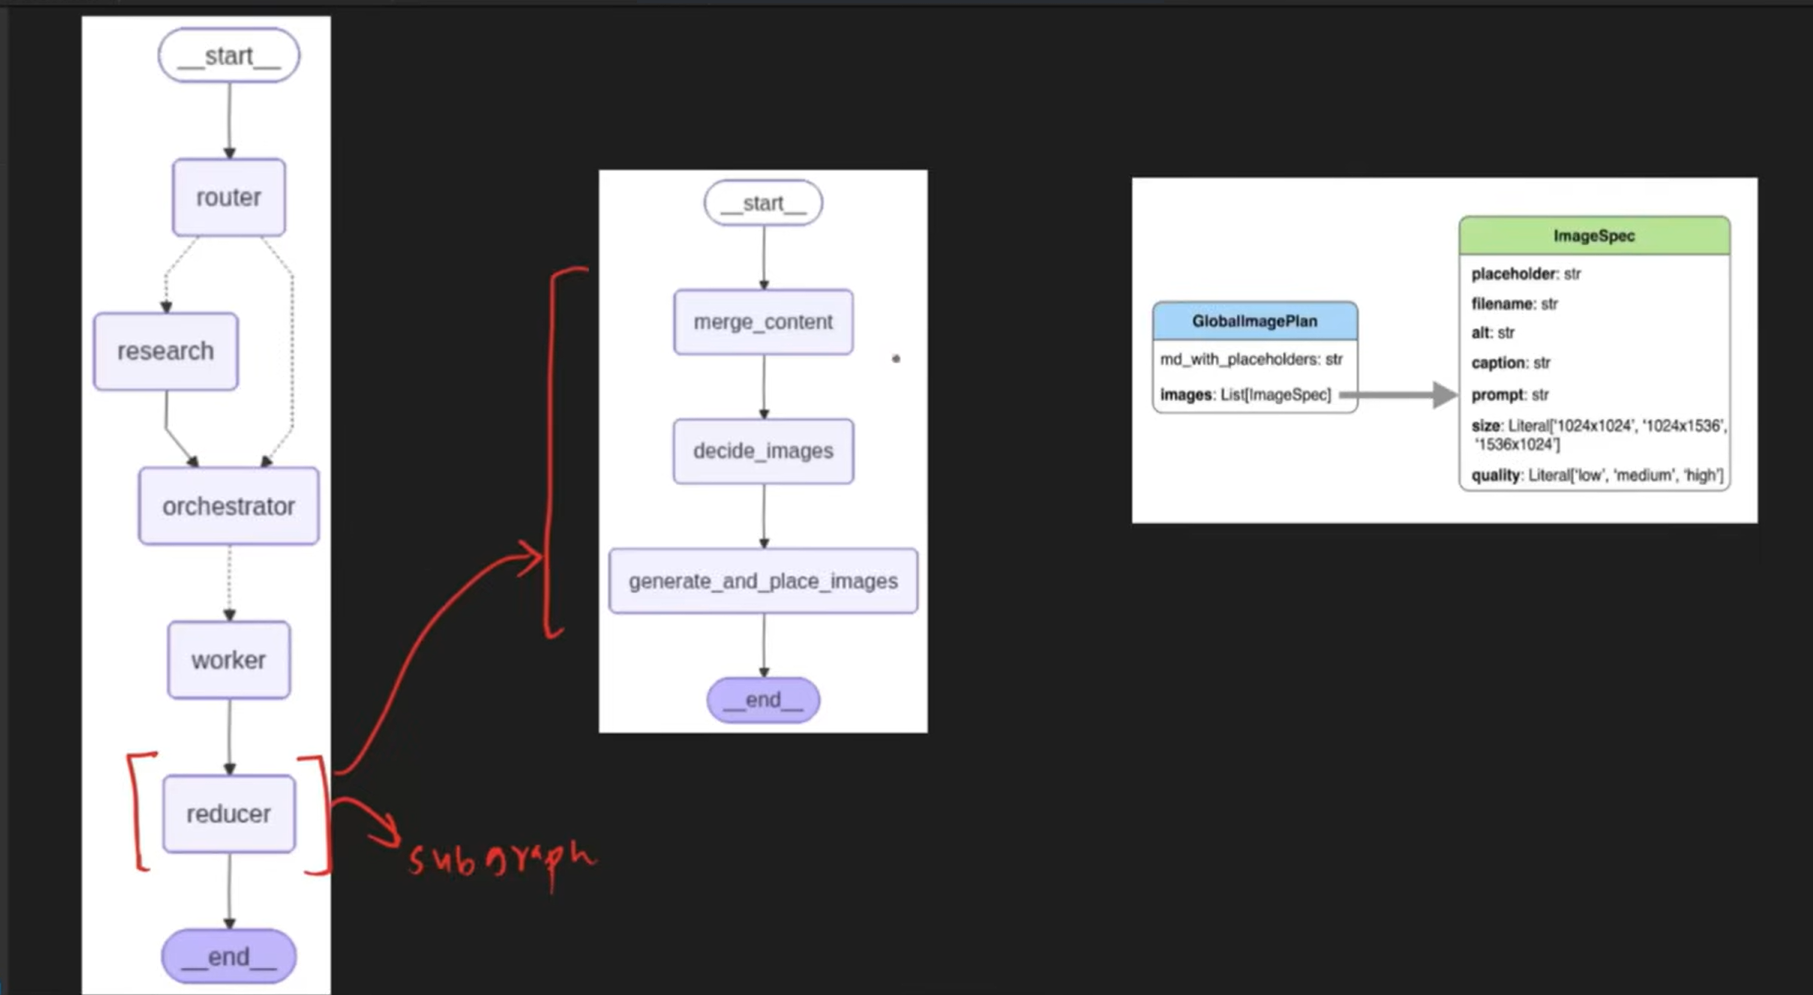

In [1]:
from __future__ import annotations

import operator
import os
from pathlib import Path
from typing import Annotated, List, Literal, Optional, TypedDict

from dotenv import load_dotenv
from groq import Groq
from pydantic import BaseModel, Field

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI

from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.types import Send
from google import genai
from google.genai import types
load_dotenv()

C:\Users\admin\AppData\Local\Temp\ipykernel_6584\4074848258.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


True

In [2]:
os.environ["LANGCHAIN_PROJECT"] = "blog writer with research agent with images"

In [3]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.3
)

In [4]:
image_planner_llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [5]:
class Task(BaseModel):
    '''
    Represents a writing task for a section of the blog post.

    Attributes:
        id: The unique identifier of the task.
        title: The title of the blog section.
        brief: A brief description of the section's content.
    '''
    id : int
    title: str = Field(..., description="The title of the blog post")
    brief: str = Field(..., description="The brief description of the blog post")
    

In [6]:
class Plan(BaseModel):
    '''
    Represents a plan for writing a blog post.
    A structured plan for generating a blog post.

    Attributes:
        blog_title: The title of the blog post.
        tasks: The ordered writing tasks required to complete the post.
    '''
    blog_title : str
    audience: str
    tasks : List[Task] = Field(..., description="The list of tasks to complete the blog post")
    


In [7]:
class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)

In [8]:
class ImageSpec(BaseModel):
    placeholder: str = Field(..., description="e.g. [[IMAGE_1]]")
    filename: str = Field(..., description="Save under images/, e.g. qkv_flow.png")
    alt: str
    caption: str
    prompt: str = Field(..., description="Prompt to send to the image model.")
    size: Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    quality: Literal["low", "medium", "high"] = "medium"


class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)
    

In [9]:
class ImagePlan(BaseModel):
    images: List[ImageSpec] = Field(
        default_factory=list
    )

In [10]:
class State(TypedDict):
    '''
    State represents the shared state of the blog-generation workflow.

    Attributes:
        plan: The structured plan containing the blog title and writing tasks.
        topic: The topic of the blog post.
        sections: The generated blog sections accumulated during execution.
        final: The completed blog post.
    '''
    topic : str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    
    sections : Annotated[List[str],operator.add] = Field(description="The list of sections to be written for the blog post")
    final : str


        # reducer/image
    merged_md: str
    md_with_placeholders: str
    image_specs: List[dict]

   

In [11]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 1-2 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

def router_node(state: State) -> dict:
    """Route the topic to research or directly to blog planning.

    Args:
        state: Current workflow state containing the topic.

    Returns:
        Routing decision with research requirement, mode, and search queries.
    """
    
    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}"),
        ]
    )

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

def route_next(state: State) -> str:
    """Return the next workflow node based on the research requirement.

    Args:
        state: Current workflow state containing the research decision.

    Returns:
        ``"research"`` when web research is required; otherwise,
        ``"orchestrator"``.
    """
    return "research" if state["needs_research"] else "orchestrator"


In [12]:
def _tavily_search(query: str, max_results: int = 2) -> List[dict]:
    """Run a Tavily web search and return normalized result dictionaries."""
    
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized

In [13]:
RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:
    """Collect and synthesize web-based evidence for the current blog topic.

    This node executes the search queries produced by the router node, combines
    the returned search results, and uses the language model to convert them
    into validated ``EvidenceItem`` objects. Evidence is filtered to entries
    with URLs and deduplicated by URL before being returned to the workflow.

    The node returns an empty evidence list when no queries are available or
    when the searches produce no results. Search failures raised by
    ``_tavily_search`` are not suppressed and will propagate to the workflow.

    Args:
        state: The current workflow state. The ``queries`` field should contain
            the web-search queries generated by the router node.

    Returns:
        A dictionary containing ``evidence``, a list of deduplicated
        ``EvidenceItem`` objects. Each item may include its title, URL,
        publication date, snippet, and source.
    """

    # take the first 10 queries from state
    queries = (state.get("queries", []) or [])
    max_results = 2

    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results:\n{raw_results}"),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {"evidence": list(dedup.values())}

In [14]:
def orchestrator(state: State) -> dict:
    """
    Generate a structured blog post plan based on the topic.
    """

    print(
        f"Generating blog plan for topic: {state['topic']}"
    )
    print(state)
    evidence = state.get("evidence", [])

    evidence_text = [
        e.model_dump()
        for e in evidence
    ][:16]

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 1-2 sections "
                    "on the following topic."
                )
            ),

            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {state['mode']}\n\n"
                    f"Evidence "
                    f"(ONLY use for fresh claims; may be empty):\n"
                    f"{evidence_text}"
                )
            )
        ]
    )

    return {
        "plan": plan
    }

In [15]:
def fanout(state: State):
    """
    Create worker tasks for each section in the generated blog plan.

    Args:
        state: The current workflow state containing the topic and blog plan.

    Returns:
        A list of Send objects that route each task to the worker node.
    """

    tasks = []

    for task in state["plan"].tasks:

        task_input = {
            "task": task,
            "topic": state["topic"],
            "mode": state["mode"],
            "evidence": [e.model_dump() for e in state.get("evidence", [])],
            "plan": state["plan"]
        }

        tasks.append(
            Send(
                "worker",
                task_input
            )
        )

    return tasks

In [16]:
WORKER_SYSTEM = """
You are a technical blog writer.

Write one clean Markdown section for the given blog.

Focus only on the assigned section.
Do not write the entire blog.
Do not add a separate conclusion unless the assigned task requires it.
"""


def worker_node(payload: dict) -> dict:
    """
    Generate one blog section based on the task assigned by fanout.
    """

    # Convert dictionaries back into Pydantic models
    task = payload["task"]
    plan = payload["plan"]

    # Convert evidence dictionaries back into EvidenceItem objects
    evidence = [
        EvidenceItem(**item)
        for item in payload.get("evidence", [])
    ]

    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    # Format evidence
    evidence_text = ""

    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | "
            f"{e.published_at or 'date:unknown'}"
            for e in evidence[:10]
        )

    # Generate the section
    response = llm.invoke(
        [
            SystemMessage(
                content=WORKER_SYSTEM
            ),

            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"

                    f"Section title: {task.title}\n"
                    f"Section brief: {task.brief}\n\n"

                    f"Evidence "
                    f"(ONLY use these URLs when citing):\n"
                    f"{evidence_text}\n"
                )
            )
        ]
    )

    section_md = response.content.strip()

    # Return task ID along with section
    # so reducer can preserve the original order
    return {
        "sections": [
            (task.id, section_md)
        ]
    }

In [17]:
def merge_content(state: State) -> dict:
    """
    Merge all generated blog sections into a single Markdown document.

    Args:
        state: The current workflow state containing the blog plan and sections.

    Returns:
        A dictionary with the merged Markdown content under the 'merged_md' key.
    """

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"
    return {"merged_md": merged_md}

In [18]:
def insert_image_placeholders(markdown: str,image_specs: list[dict]) -> str:

    if not image_specs:
        return markdown

    sections = markdown.split("\n## ")

    output = sections[0]

    for i, section in enumerate(sections[1:], start=1):

        output += "\n## " + section

        if i <= len(image_specs):

            placeholder = image_specs[i - 1]["placeholder"]

            output += f"\n\n{placeholder}\n"

    return output

In [19]:
DECIDE_IMAGES_SYSTEM = """
You are an expert technical editor.

Analyze the blog and decide whether images or diagrams
would materially improve understanding.

Rules:

- Maximum 3 images.
- Prefer technical diagrams, flowcharts, timelines,
  architecture diagrams, or useful data visualizations.
- Avoid decorative images.
- Each image must have a clear purpose.
- Return ONLY ImagePlan.
- The placeholder must be exactly:
  [[IMAGE_1]], [[IMAGE_2]], or [[IMAGE_3]].
- Do not return Markdown.
- Do not return the complete blog.
"""

In [20]:
def decide_images(state: State) -> dict:

    planner = image_planner_llm.with_structured_output(
        ImagePlan
    )

    merged_md = state["merged_md"]

    image_plan = planner.invoke(
        [
            SystemMessage(
                content=DECIDE_IMAGES_SYSTEM
            ),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n\n"
                    f"Blog:\n{merged_md}"
                )
            )
        ]
    )

    image_specs = [
        image.model_dump()
        for image in image_plan.images
    ]

    md_with_placeholders = insert_image_placeholders(
        merged_md,
        image_specs
    )

    return {
        "md_with_placeholders": md_with_placeholders,
        "image_specs": image_specs
    }

In [21]:
def _gemini_generate_image_bytes(prompt: str) -> bytes:
    """
    Returns raw image bytes generated by Gemini.
    Requires: pip install google-genai
    Env var: GOOGLE_API_KEY
    """
    

    api_key = os.environ.get("GOOGLE_API_KEY")
    if not api_key:
        raise RuntimeError("GOOGLE_API_KEY is not set.")

    client = genai.Client(api_key=api_key)

    resp = client.models.generate_content(
        model="gemini-2.5-flash-image",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE"],
            safety_settings=[
                types.SafetySetting(
                    category="HARM_CATEGORY_DANGEROUS_CONTENT",
                    threshold="BLOCK_ONLY_HIGH",
                )
            ],
        ),
    )

    # Depending on SDK version, parts may hang off resp.candidates[0].content.parts
    parts = getattr(resp, "parts", None)
    if not parts and getattr(resp, "candidates", None):
        try:
            parts = resp.candidates[0].content.parts
        except Exception:
            parts = None

    if not parts:
        raise RuntimeError("No image content returned (safety/quota/SDK change).")

    for part in parts:
        inline = getattr(part, "inline_data", None)
        if inline and getattr(inline, "data", None):
            return inline.data

    raise RuntimeError("No inline image bytes found in response.")




In [22]:
# from pathlib import Path


# def reducer(state: State) -> dict:
#     """Assemble the generated sections into a Markdown blog post and save it."""

#     title = state["plan"].blog_title

#     # Sort sections according to task ID
#     ordered_sections = sorted(
#         state["sections"],
#         key=lambda x: x[0]
#     )

#     # Extract only the generated Markdown
#     body = "\n\n".join(
#         section
#         for _, section in ordered_sections
#     ).strip()

#     # # Create final Markdown
#     final_md = f"# {title}\n\n{body}\n"

#     # # Create output folder
#     # output_dir = Path("blogs_generated")
#     # output_dir.mkdir(
#     #     parents=True,
#     #     exist_ok=True
#     # )

#     # # Create filename
#     # filename = title.lower().replace(" ", "_") + ".md"

#     # output_path = output_dir / filename

#     # # Save file
#     # output_path.write_text(
#     #     final_md,
#     #     encoding="utf-8"
#     # )

#     # print(f"Blog saved to: {output_path.resolve()}")

#     return {
#         "final": final_md
#     }

In [23]:
def generate_and_place_images(state: State) -> dict:
    """
    Generate images for the blog and embed them into the markdown.

    Args:
        state: The current workflow state containing the blog markdown and image specifications.

    Returns:
        A dictionary with the final markdown content (with embedded images) under the 'final' key.
    """

    plan = state["plan"]
    assert plan is not None

    md = state.get("md_with_placeholders") or state["merged_md"]
    image_specs = state.get("image_specs", []) or []

    # If no images requested, just write merged markdown
    if not image_specs:
        filename = f"{plan.blog_title}.md"
        Path(filename).write_text(md, encoding="utf-8")
        return {"final": md}

    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    for spec in image_specs:
        placeholder = spec["placeholder"]
        filename = spec["filename"]
        out_path = images_dir / filename

        # generate only if needed
        if not out_path.exists():
            try:
                img_bytes = _gemini_generate_image_bytes(spec["prompt"])
                out_path.write_bytes(img_bytes)
            except Exception as e:
                # graceful fallback: keep doc usable
                prompt_block = (
                    f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
                    f"> **Alt:** {spec.get('alt','')}\n>\n"
                    f"> **Prompt:** {spec.get('prompt','')}\n>\n"
                    f"> **Error:** {e}\n"
                )
                md = md.replace(placeholder, prompt_block)
                continue

        img_md = f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
        md = md.replace(placeholder, img_md)

    # filename = f"{plan.blog_title}.md"
    # Path(filename).write_text(md, encoding="utf-8")
    return {"final": md}

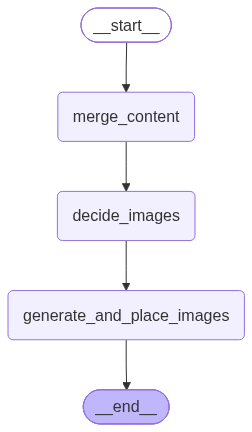

In [24]:
# build reducer subgraph
reducer_graph = StateGraph(State)
reducer_graph.add_node("merge_content", merge_content)
reducer_graph.add_node("decide_images", decide_images)
reducer_graph.add_node("generate_and_place_images", generate_and_place_images)
reducer_graph.add_edge(START, "merge_content")
reducer_graph.add_edge("merge_content", "decide_images")
reducer_graph.add_edge("decide_images", "generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images", END)
reducer_subgraph = reducer_graph.compile()

reducer_subgraph

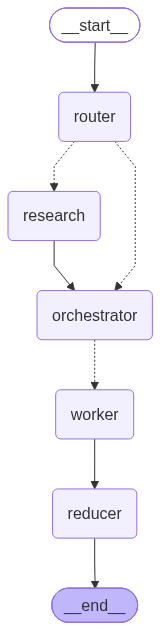

In [25]:
# -----------------------------
# 9) Build main graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_subgraph)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [26]:
question = "What are the recent developments in Indian Stock Market?"
output = app.invoke({"topic":question })

C:\Users\admin\AppData\Local\Temp\ipykernel_6584\649868137.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=max_results)


Generating blog plan for topic: What are the recent developments in Indian Stock Market?
{'topic': 'What are the recent developments in Indian Stock Market?', 'mode': 'open_book', 'needs_research': True, 'queries': ['Indian stock market major index performance July 2026', 'latest SEBI regulatory changes affecting Indian equities 2026'], 'evidence': [EvidenceItem(title='Indian Markets Outperform Global Peers in July', url='https://www.rediff.com/business/report/indian-markets-outperform-global-peers-in-july/20260801.htm', published_at=None, snippet='July lived up to its reputation of being a strong month for Indian equity benchmarks, with the Nifty gaining 2.2% and the Sensex rising 2.1%. Strong June‑quarter earnings and a return of foreign portfolio investors supported the rally.', source='Rediff'), EvidenceItem(title='SEBI’S 2026 Buy-Back Reforms: What Listed Companies And Promoters Need To Know', url='https://www.mondaq.com/india/shareholders/1834328/sebis-2026-buy-back-reforms-what-

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [27]:
llm_title = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.9
)

response = llm_title.invoke(
    [
        SystemMessage(
            content="Generate a concise and engaging blog title."
        ),
        HumanMessage(
            content=f"Topic: {question}"
        )
    ]
)

title = response.content

print(title)

**India’s Stock Market 2024: Key Trends, Surprises & What’s Driving the Surge**


In [28]:
from pathlib import Path
import re

# Create folder
output_dir = Path("blogs_generated_new")
output_dir.mkdir(parents=True, exist_ok=True)

# Make title filename-safe
safe_title = re.sub(
    r"[^a-zA-Z0-9]+",
    "_",
    title
).strip("_").lower()

# Create filename
filename = f"{safe_title}_blog.md"

# Create file path
output_path = output_dir / filename

# Write content
output_path.write_text(
    output["final"],
    encoding="utf-8"
)

print(f"Saved to: {output_path.resolve()}")

Saved to: D:\Lang Graph\Agentic-AI-LANGRAPH\8_Planning Agents\blogs_generated_new\india_s_stock_market_2024_key_trends_surprises_what_s_driving_the_surge_blog.md
